In [1]:
# ============ HÜCRE 1 — Kurulum + Tohum ============
import sys
sys.path.append('F:/CancerDataClassification/src')

import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib, random

import dataset
importlib.reload(dataset)
from dataset import HAMDataset, get_transforms, get_weighted_sampler

from models import pretrained_models
importlib.reload(pretrained_models)
from models.pretrained_models import get_model, count_parameters

import train as train_module
importlib.reload(train_module)
from train import train_model

from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42   # <-- HER KOŞUDA SADECE BURASI DEĞİŞİR: 13, sonra 21, sonra 42
set_seed(SEED)

BASE = Path('F:/CancerDataClassification')
DATA = BASE / 'data'
MODELS_LEAK_DIR = BASE / 'models/leakage_experiment'
MODELS_LEAK_DIR.mkdir(parents=True, exist_ok=True)

# Bu tohumun grafikleri buraya kaydedilecek (otomatik)
FIG_DIR = BASE / f'results/figures/seed{SEED}'
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda')
print(f"Tohum: {SEED} | Grafik klasörü: {FIG_DIR} | GPU: {torch.cuda.get_device_name(0)}")

C:\Users\Lada\.conda\envs\cancer_cls\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info The read operation timed out
  data = fetch_version_info()


Tohum: 42 | Grafik klasörü: F:\CancerDataClassification\results\figures\seed42 | GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ============ HÜCRE 2 — Worst-Case Sızıntı Ayarları ============
import shutil, cv2
import albumentations as A
from tqdm import tqdm

set_seed(SEED)   # sızıntılı veri üretiminden önce tohumu tazele

ORIGINAL = DATA / 'original'
WORST_DATA = DATA / 'worst_leakage'
TARGET_PER_CLASS = 700          # 500 train + 100 val + 100 test
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print(f"Hedef: {TARGET_PER_CLASS} resim/sınıf, toplam {TARGET_PER_CLASS*7}")

Hedef: 700 resim/sınıf, toplam 4900


In [3]:
# ============ HÜCRE 3 — Augmentation Pipeline (sızıntı için) ============
augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1),
             rotate=(-20, 20), border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.4),
    A.GaussNoise(std_range=(0.02, 0.06), p=0.2),
])
print("Augmentation pipeline hazır")

Augmentation pipeline hazır


In [4]:
# ============ HÜCRE 4 — Her Sınıftan 700 Augment Resim Üret (diske) ============
if WORST_DATA.exists():
    shutil.rmtree(WORST_DATA)

for cls in class_names:
    src_folder = ORIGINAL / cls
    dst_folder = WORST_DATA / cls
    dst_folder.mkdir(parents=True, exist_ok=True)

    images = list(src_folder.glob('*.jpg')) + list(src_folder.glob('*.png'))
    n_original = len(images)
    print(f"{cls}: {n_original} orijinal -> {TARGET_PER_CLASS} augment")

    for i in tqdm(range(TARGET_PER_CLASS), desc=cls):
        src_img_path = images[i % n_original]
        img = cv2.imread(str(src_img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_aug = augment_pipeline(image=img)['image']
        img_aug = cv2.cvtColor(img_aug, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(dst_folder / f'{cls}_aug_{i:04d}.jpg'), img_aug)

print("Tüm augment resimler kaydedildi")

akiec: 327 orijinal -> 700 augment


akiec: 100%|█████████████████████████████████████████████████████████████████████████| 700/700 [00:09<00:00, 70.35it/s]


bcc: 514 orijinal -> 700 augment


bcc: 100%|███████████████████████████████████████████████████████████████████████████| 700/700 [00:11<00:00, 60.81it/s]


bkl: 1099 orijinal -> 700 augment


...

nv: 6705 orijinal -> 700 augment


nv: 100%|████████████████████████████████████████████████████████████████████████████| 700/700 [00:14<00:00, 49.71it/s]


vasc: 142 orijinal -> 700 augment


vasc: 100%|██████████████████████████████████████████████████████████████████████████| 700/700 [00:07<00:00, 95.65it/s]

Tüm augment resimler kaydedildi


In [5]:
# ============ HÜCRE 5 — Rastgele Bölme 500/100/100 (SIZINTI burada oluşur) ============
train_records, val_records, test_records = [], [], []

for cls in class_names:
    images = sorted(list((WORST_DATA / cls).glob('*.jpg')))
    random.shuffle(images)
    train_imgs, val_imgs, test_imgs = images[:500], images[500:600], images[600:700]
    print(f"{cls}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

    for group, recs in [(train_imgs, train_records),
                        (val_imgs, val_records),
                        (test_imgs, test_records)]:
        for p in group:
            recs.append({
                'image_path': str(p),
                'dx': cls,
                'binary': 'malignant' if cls in ['mel', 'bcc', 'akiec'] else 'benign'
            })

pd.DataFrame(train_records).to_csv(DATA / 'worst_train.csv', index=False)
pd.DataFrame(val_records).to_csv(DATA / 'worst_val.csv', index=False)
pd.DataFrame(test_records).to_csv(DATA / 'worst_test.csv', index=False)
print("Sızıntılı CSV'ler kaydedildi (aynı orijinalin varyasyonları farklı setlerde)")

akiec: train=500, val=100, test=100
bcc: train=500, val=100, test=100
bkl: train=500, val=100, test=100
df: train=500, val=100, test=100
mel: train=500, val=100, test=100
nv: train=500, val=100, test=100
vasc: train=500, val=100, test=100
Sızıntılı CSV'ler kaydedildi (aynı orijinalin varyasyonları farklı setlerde)


In [6]:
# ============ HÜCRE 6 — DataLoader (Worst-Case) ============
IMAGE_SIZE = 300
BATCH_SIZE = 16

train_dataset_worst = HAMDataset(
    csv_path=str(DATA / 'worst_train.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='train', use_augmentation=True))
val_dataset_worst = HAMDataset(
    csv_path=str(DATA / 'worst_val.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='val'))

train_loader_worst = DataLoader(train_dataset_worst, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=0, pin_memory=True)
val_loader_worst = DataLoader(val_dataset_worst, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset_worst)} | Val: {len(val_dataset_worst)}")

Train: 3500 | Val: 700


# DenseNet121

In [7]:
# ============ HÜCRE 7 — DenseNet121 Eğitim ============
set_seed(SEED)
model = get_model('densenet121', num_classes=7, pretrained=True)
print(f"DenseNet121 | Parametreler: {count_parameters(model):,}")

history_densenet_worst = train_model(
    model=model, train_loader=train_loader_worst, val_loader=val_loader_worst,
    epochs=30, max_lr=0.0008,
    save_path=str(MODELS_LEAK_DIR / 'densenet121_WORST.pth'),
    device=device, pct_start=0.3)

DenseNet121 | Parametreler: 6,961,031
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\leakage_experiment\densenet121_WORST.pth


Epoch   1/30 | Train Loss: 1.8610 Acc: 26.97% | Val Loss: 1.6694 Acc: 40.71% | LR: 0.00006 | Time: 121.4s
   💾 Best model saved! Val Acc: 40.71%


Epoch   2/30 | Train Loss: 1.5594 Acc: 45.43% | Val Loss: 1.2649 Acc: 57.00% | LR: 0.00012 | Time: 61.6s
   💾 Best model saved! Val Acc: 57.00%


Epoch   3/30 | Train Loss: 1.2184 Acc: 57.00% | Val Loss: 0.9558 Acc: 65.14% | LR: 0.00022 | Time: 61.4s
   💾 Best model saved! Val Acc: 65.14%


Epoch   4/30 | Train Loss: 0.9905 Acc: 64.14% | Val Loss: 0.8050 Acc: 71.57% | LR: 0.00035 | Time: 61.1s
   💾 Best model saved! Val Acc: 71.57%


...

Epoch  26/30 | Train Loss: 0.2415 Acc: 91.77% | Val Loss: 0.3915 Acc: 87.57% | LR: 0.00007 | Time: 60.1s
   💾 Best model saved! Val Acc: 87.57%


Epoch  27/30 | Train Loss: 0.2242 Acc: 92.60% | Val Loss: 0.3741 Acc: 87.57% | LR: 0.00004 | Time: 60.1s


Epoch  28/30 | Train Loss: 0.2021 Acc: 93.54% | Val Loss: 0.3791 Acc: 87.00% | LR: 0.00002 | Time: 60.1s


Epoch  29/30 | Train Loss: 0.2011 Acc: 93.09% | Val Loss: 0.3772 Acc: 87.00% | LR: 0.00000 | Time: 60.0s


Epoch  30/30 | Train Loss: 0.2155 Acc: 92.77% | Val Loss: 0.3728 Acc: 87.57% | LR: 0.00000 | Time: 60.2s

EĞİTİM BİTTİ - Toplam süre: 31.2 dakika
En iyi Val Acc: 87.57%
Model kaydedildi: F:\CancerDataClassification\models\leakage_experiment\densenet121_WORST.pth


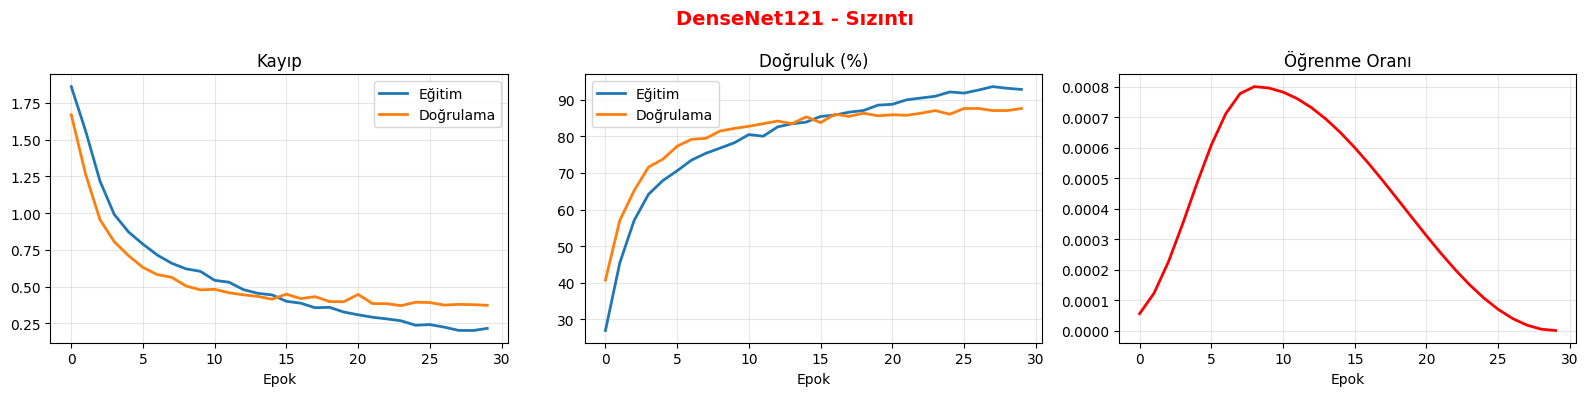

In [8]:
# ============ HÜCRE 8 — DenseNet121 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_densenet_worst['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_densenet_worst['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_densenet_worst['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_densenet_worst['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_densenet_worst['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle('DenseNet121 - Sızıntı', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig(FIG_DIR / 'densenet_worst_leakage_training.png', dpi=150)
plt.show()

DenseNet121 Sızıntı | Doğruluk %87.57 | Makro F1 %87.49
              precision    recall  f1-score   support

       akiec      0.937     0.890     0.913       100
         bcc      0.895     0.940     0.917       100
         bkl      0.831     0.690     0.754       100
          df      0.962     1.000     0.980       100
         mel      0.727     0.800     0.762       100
          nv      0.786     0.810     0.798       100
        vasc      1.000     1.000     1.000       100

    accuracy                          0.876       700
   macro avg      0.877     0.876     0.875       700
weighted avg      0.877     0.876     0.875       700



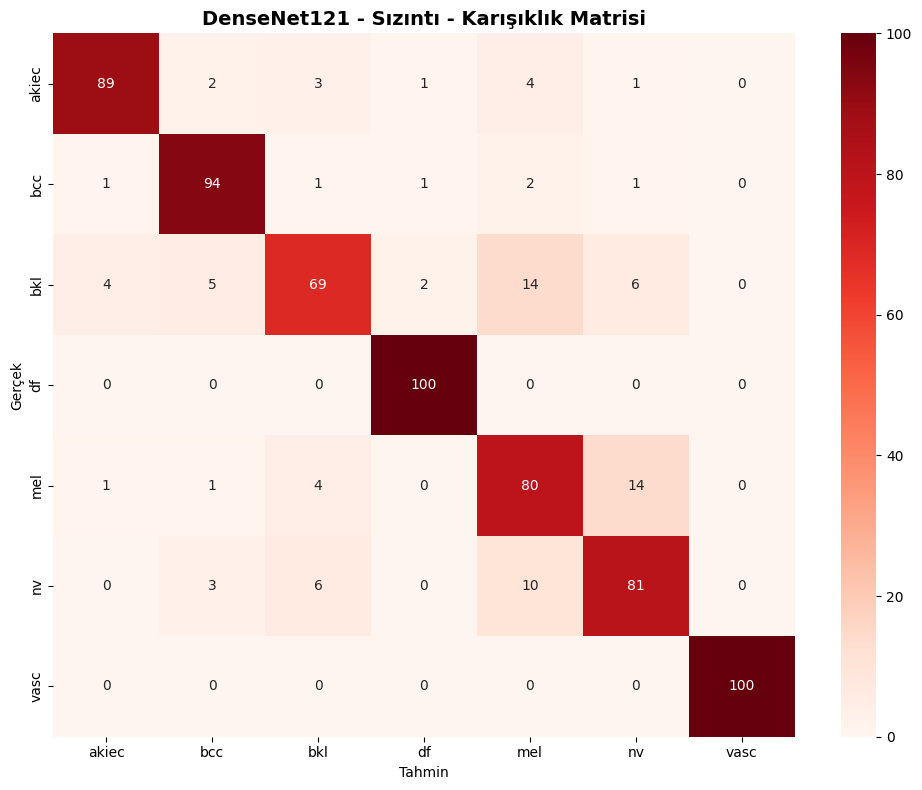

In [9]:
# ============ HÜCRE 9 — DenseNet121 Değerlendirme (val) ============
checkpoint = torch.load(MODELS_LEAK_DIR / 'densenet121_WORST.pth', map_location=device, weights_only=False)
model = get_model('densenet121', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader_worst:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc_densenet_worst = accuracy_score(all_labels, all_preds)
macro_f1_densenet_worst = f1_score(all_labels, all_preds, average='macro')
print(f"DenseNet121 Sızıntı | Doğruluk %{acc_densenet_worst*100:.2f} | Makro F1 %{macro_f1_densenet_worst*100:.2f}")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('DenseNet121 - Sızıntı - Karışıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig(FIG_DIR / 'densenet_worst_leakage_cm.png', dpi=150)
plt.show()

# ConvNeXt-Tiny

In [10]:
# ============ HÜCRE 10 — ConvNeXt-Tiny Eğitim ============
set_seed(SEED)
model = get_model('convnext_tiny', num_classes=7, pretrained=True)
print(f"ConvNeXt-Tiny | Parametreler: {count_parameters(model):,}")

history_convnext_worst = train_model(
    model=model, train_loader=train_loader_worst, val_loader=val_loader_worst,
    epochs=30, max_lr=0.0005,
    save_path=str(MODELS_LEAK_DIR / 'convnext_tiny_WORST.pth'),
    device=device, pct_start=0.3)

ConvNeXt-Tiny | Parametreler: 27,825,511
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0005
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\leakage_experiment\convnext_tiny_WORST.pth


Epoch   1/30 | Train Loss: 1.8901 Acc: 22.83% | Val Loss: 1.7056 Acc: 38.57% | LR: 0.00003 | Time: 92.0s
   💾 Best model saved! Val Acc: 38.57%


Epoch   2/30 | Train Loss: 1.5625 Acc: 43.17% | Val Loss: 1.2632 Acc: 56.29% | LR: 0.00008 | Time: 91.7s
   💾 Best model saved! Val Acc: 56.29%


Epoch   3/30 | Train Loss: 1.2591 Acc: 54.03% | Val Loss: 1.1051 Acc: 59.14% | LR: 0.00014 | Time: 91.9s
   💾 Best model saved! Val Acc: 59.14%


Epoch   4/30 | Train Loss: 1.1148 Acc: 58.69% | Val Loss: 0.9689 Acc: 64.14% | LR: 0.00022 | Time: 91.8s
   💾 Best model saved! Val Acc: 64.14%


...

Epoch  26/30 | Train Loss: 0.3524 Acc: 87.54% | Val Loss: 0.4819 Acc: 83.14% | LR: 0.00004 | Time: 91.8s


Epoch  27/30 | Train Loss: 0.3411 Acc: 87.77% | Val Loss: 0.4808 Acc: 83.00% | LR: 0.00002 | Time: 91.7s


Epoch  28/30 | Train Loss: 0.3273 Acc: 88.00% | Val Loss: 0.4721 Acc: 82.71% | LR: 0.00001 | Time: 91.8s


Epoch  29/30 | Train Loss: 0.3133 Acc: 88.86% | Val Loss: 0.4660 Acc: 83.14% | LR: 0.00000 | Time: 91.8s


Epoch  30/30 | Train Loss: 0.3053 Acc: 89.80% | Val Loss: 0.4650 Acc: 83.57% | LR: 0.00000 | Time: 91.7s

EĞİTİM BİTTİ - Toplam süre: 45.9 dakika
En iyi Val Acc: 83.71%
Model kaydedildi: F:\CancerDataClassification\models\leakage_experiment\convnext_tiny_WORST.pth


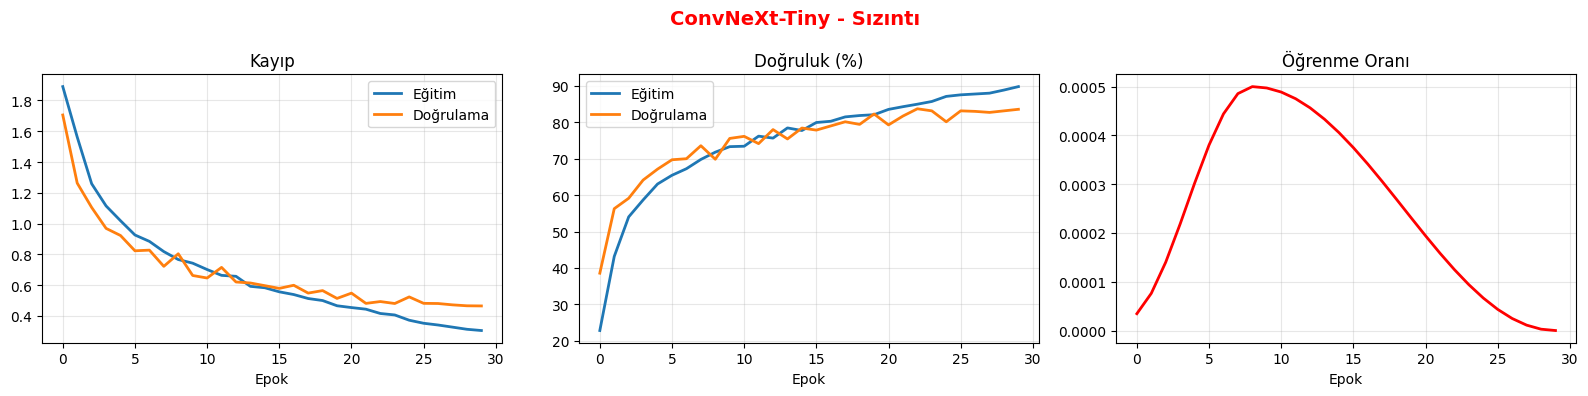

In [11]:
# ============ HÜCRE 11 — ConvNeXt-Tiny Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_convnext_worst['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_convnext_worst['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_convnext_worst['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_convnext_worst['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_convnext_worst['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle('ConvNeXt-Tiny - Sızıntı', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig(FIG_DIR / 'convnext_worst_leakage_training.png', dpi=150)
plt.show()

ConvNeXt-Tiny Sızıntı | Doğruluk %83.71 | Makro F1 %83.54
              precision    recall  f1-score   support

       akiec      0.833     0.850     0.842       100
         bcc      0.845     0.930     0.886       100
         bkl      0.670     0.690     0.680       100
          df      0.970     0.980     0.975       100
         mel      0.690     0.800     0.741       100
          nv      0.924     0.610     0.735       100
        vasc      0.980     1.000     0.990       100

    accuracy                          0.837       700
   macro avg      0.845     0.837     0.835       700
weighted avg      0.845     0.837     0.835       700



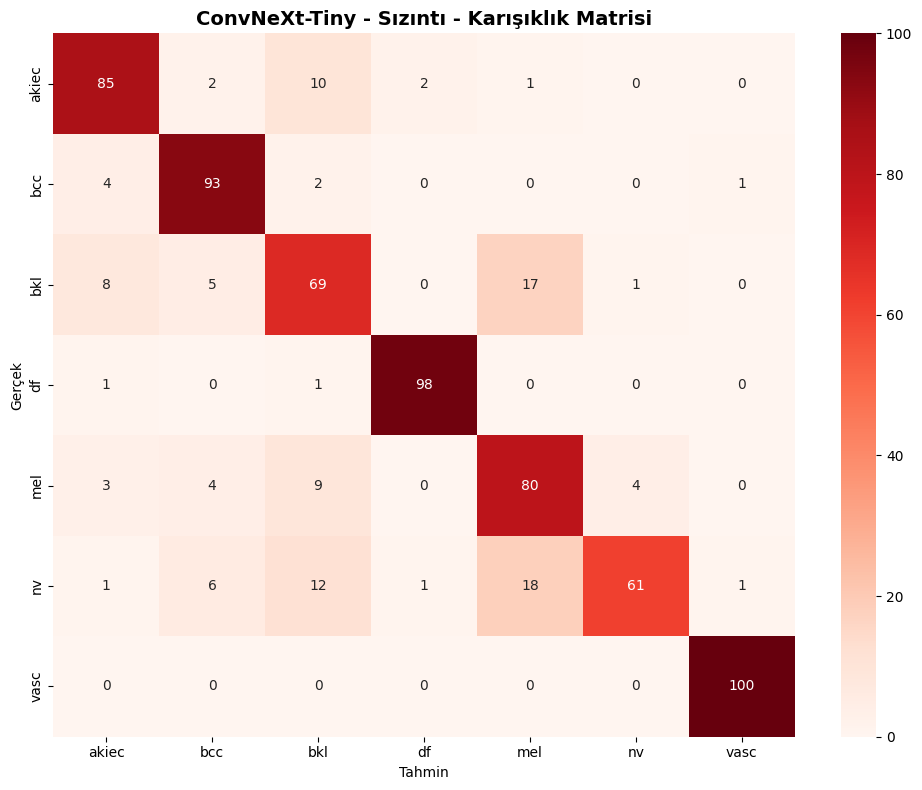

In [12]:
# ============ HÜCRE 12 — ConvNeXt-Tiny Değerlendirme (val) ============
checkpoint = torch.load(MODELS_LEAK_DIR / 'convnext_tiny_WORST.pth', map_location=device, weights_only=False)
model = get_model('convnext_tiny', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader_worst:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc_convnext_worst = accuracy_score(all_labels, all_preds)
macro_f1_convnext_worst = f1_score(all_labels, all_preds, average='macro')
print(f"ConvNeXt-Tiny Sızıntı | Doğruluk %{acc_convnext_worst*100:.2f} | Makro F1 %{macro_f1_convnext_worst*100:.2f}")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('ConvNeXt-Tiny - Sızıntı - Karışıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig(FIG_DIR / 'convnext_worst_leakage_cm.png', dpi=150)
plt.show()

# ResNet50 - WORST CASE EĞİTİM

In [13]:
# ============ HÜCRE 13 — ResNet50 Eğitim ============
set_seed(SEED)
model = get_model('resnet50', num_classes=7, pretrained=True)
print(f"ResNet50 | Parametreler: {count_parameters(model):,}")

history_resnet_worst = train_model(
    model=model, train_loader=train_loader_worst, val_loader=val_loader_worst,
    epochs=30, max_lr=0.0008,
    save_path=str(MODELS_LEAK_DIR / 'resnet50_WORST.pth'),
    device=device, pct_start=0.3)

ResNet50 | Parametreler: 23,522,375
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\leakage_experiment\resnet50_WORST.pth


Epoch   1/30 | Train Loss: 1.9227 Acc: 19.80% | Val Loss: 1.8925 Acc: 26.14% | LR: 0.00006 | Time: 59.1s
   💾 Best model saved! Val Acc: 26.14%


Epoch   2/30 | Train Loss: 1.8772 Acc: 29.86% | Val Loss: 1.8078 Acc: 41.29% | LR: 0.00012 | Time: 59.1s
   💾 Best model saved! Val Acc: 41.29%


Epoch   3/30 | Train Loss: 1.7787 Acc: 38.51% | Val Loss: 1.6563 Acc: 48.43% | LR: 0.00022 | Time: 59.0s
   💾 Best model saved! Val Acc: 48.43%


Epoch   4/30 | Train Loss: 1.6231 Acc: 44.63% | Val Loss: 1.4399 Acc: 53.14% | LR: 0.00035 | Time: 59.1s
   💾 Best model saved! Val Acc: 53.14%


...

Epoch  26/30 | Train Loss: 0.4212 Acc: 85.54% | Val Loss: 0.4912 Acc: 82.43% | LR: 0.00007 | Time: 58.8s


Epoch  27/30 | Train Loss: 0.4137 Acc: 85.74% | Val Loss: 0.4794 Acc: 82.43% | LR: 0.00004 | Time: 58.8s


Epoch  28/30 | Train Loss: 0.4018 Acc: 85.06% | Val Loss: 0.4950 Acc: 82.43% | LR: 0.00002 | Time: 58.9s


Epoch  29/30 | Train Loss: 0.3835 Acc: 86.66% | Val Loss: 0.4873 Acc: 83.29% | LR: 0.00000 | Time: 58.9s
   💾 Best model saved! Val Acc: 83.29%


Epoch  30/30 | Train Loss: 0.3971 Acc: 85.40% | Val Loss: 0.4833 Acc: 83.43% | LR: 0.00000 | Time: 58.9s
   💾 Best model saved! Val Acc: 83.43%

EĞİTİM BİTTİ - Toplam süre: 29.5 dakika
En iyi Val Acc: 83.43%
Model kaydedildi: F:\CancerDataClassification\models\leakage_experiment\resnet50_WORST.pth


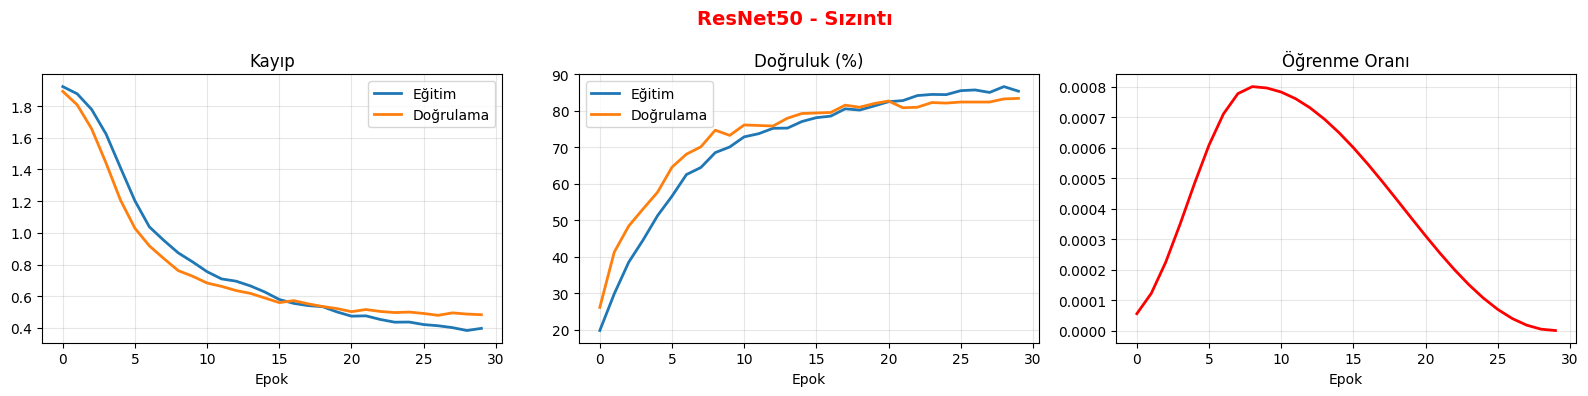

In [14]:
# ============ HÜCRE 14 — ResNet50 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_resnet_worst['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_resnet_worst['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_resnet_worst['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_resnet_worst['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_resnet_worst['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle('ResNet50 - Sızıntı', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig(FIG_DIR / 'resnet50_worst_leakage_training.png', dpi=150)
plt.show()

ResNet50 Sızıntı | Doğruluk %83.43 | Makro F1 %83.37
              precision    recall  f1-score   support

       akiec      0.848     0.780     0.812       100
         bcc      0.871     0.880     0.876       100
         bkl      0.652     0.750     0.698       100
          df      0.926     1.000     0.962       100
         mel      0.750     0.690     0.719       100
          nv      0.813     0.740     0.775       100
        vasc      0.990     1.000     0.995       100

    accuracy                          0.834       700
   macro avg      0.836     0.834     0.834       700
weighted avg      0.836     0.834     0.834       700



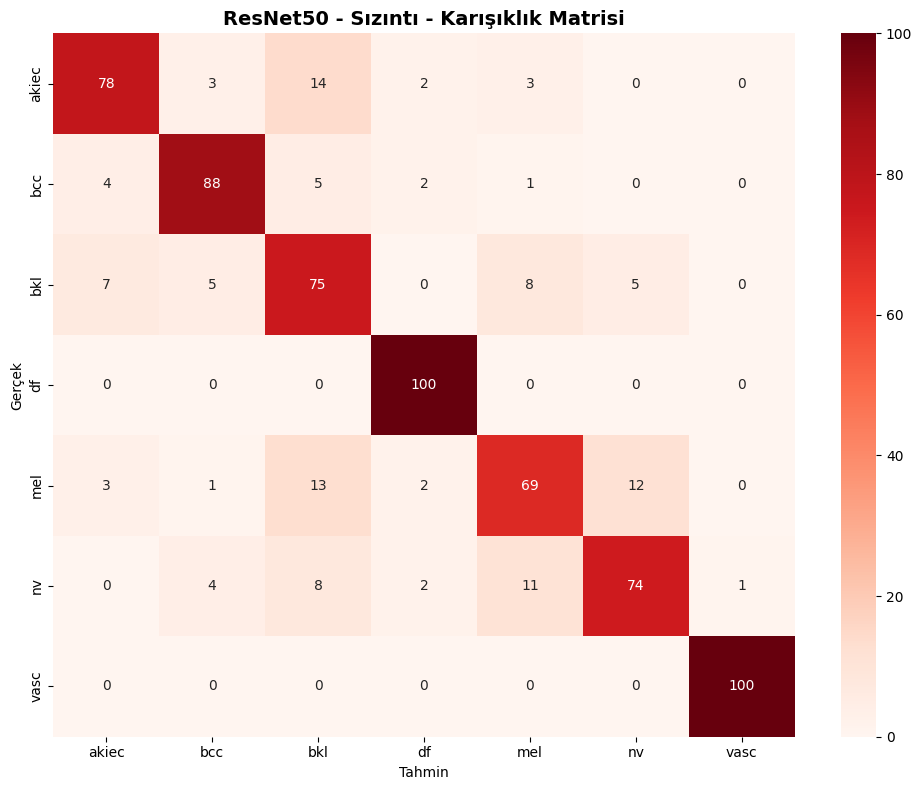

In [15]:
# ============ HÜCRE 15 — ResNet50 Değerlendirme (val) ============
checkpoint = torch.load(MODELS_LEAK_DIR / 'resnet50_WORST.pth', map_location=device, weights_only=False)
model = get_model('resnet50', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader_worst:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc_resnet_worst = accuracy_score(all_labels, all_preds)
macro_f1_resnet_worst = f1_score(all_labels, all_preds, average='macro')
print(f"ResNet50 Sızıntı | Doğruluk %{acc_resnet_worst*100:.2f} | Makro F1 %{macro_f1_resnet_worst*100:.2f}")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('ResNet50 - Sızıntı - Karışıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig(FIG_DIR / 'resnet50_worst_leakage_cm.png', dpi=150)
plt.show()

# EfficientNet-B3 - WORST CASE EĞİTİM

In [16]:
# ============ HÜCRE 16 — EfficientNet-B3 Eğitim ============
set_seed(SEED)
model = get_model('efficientnet_b3', num_classes=7, pretrained=True)
print(f"EfficientNet-B3 | Parametreler: {count_parameters(model):,}")

history_b3_worst = train_model(
    model=model, train_loader=train_loader_worst, val_loader=val_loader_worst,
    epochs=30, max_lr=0.0008,
    save_path=str(MODELS_LEAK_DIR / 'efficientnet_b3_WORST.pth'),
    device=device, pct_start=0.3)

EfficientNet-B3 | Parametreler: 10,706,991
TRAINING BAŞLADI
Epochs: 30
Max LR: 0.0008
Total steps: 6570
Device: cuda
Save path: F:\CancerDataClassification\models\leakage_experiment\efficientnet_b3_WORST.pth


Epoch   1/30 | Train Loss: 1.9396 Acc: 15.91% | Val Loss: 1.9069 Acc: 21.71% | LR: 0.00006 | Time: 75.2s
   💾 Best model saved! Val Acc: 21.71%


Epoch   2/30 | Train Loss: 1.8914 Acc: 25.31% | Val Loss: 1.8338 Acc: 34.86% | LR: 0.00012 | Time: 75.1s
   💾 Best model saved! Val Acc: 34.86%


Epoch   3/30 | Train Loss: 1.8145 Acc: 34.11% | Val Loss: 1.7114 Acc: 45.00% | LR: 0.00022 | Time: 75.2s
   💾 Best model saved! Val Acc: 45.00%


Epoch   4/30 | Train Loss: 1.7016 Acc: 41.17% | Val Loss: 1.5335 Acc: 54.14% | LR: 0.00035 | Time: 75.0s
   💾 Best model saved! Val Acc: 54.14%


...

Epoch  26/30 | Train Loss: 0.6231 Acc: 77.23% | Val Loss: 0.5441 Acc: 79.57% | LR: 0.00007 | Time: 75.0s


Epoch  27/30 | Train Loss: 0.6200 Acc: 77.17% | Val Loss: 0.5187 Acc: 80.86% | LR: 0.00004 | Time: 75.0s
   💾 Best model saved! Val Acc: 80.86%


Epoch  28/30 | Train Loss: 0.6187 Acc: 76.46% | Val Loss: 0.5152 Acc: 80.14% | LR: 0.00002 | Time: 75.0s


Epoch  29/30 | Train Loss: 0.6069 Acc: 77.43% | Val Loss: 0.5248 Acc: 80.86% | LR: 0.00000 | Time: 75.1s


Epoch  30/30 | Train Loss: 0.5987 Acc: 78.40% | Val Loss: 0.5293 Acc: 79.86% | LR: 0.00000 | Time: 74.9s

EĞİTİM BİTTİ - Toplam süre: 37.5 dakika
En iyi Val Acc: 80.86%
Model kaydedildi: F:\CancerDataClassification\models\leakage_experiment\efficientnet_b3_WORST.pth


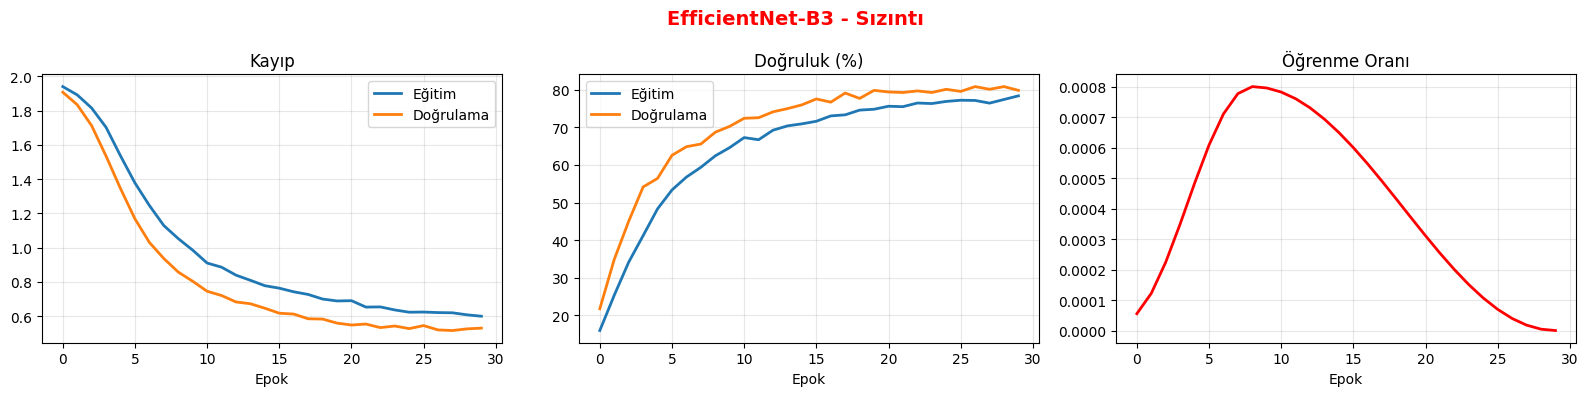

In [17]:
# ============ HÜCRE 17 — EfficientNet-B3 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_b3_worst['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_b3_worst['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_b3_worst['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_b3_worst['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_b3_worst['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle('EfficientNet-B3 - Sızıntı', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig(FIG_DIR / 'efficientnet_b3_worst_leakage_training.png', dpi=150)
plt.show()

EfficientNet-B3 Sızıntı | Doğruluk %80.86 | Makro F1 %80.69
              precision    recall  f1-score   support

       akiec      0.813     0.740     0.775       100
         bcc      0.830     0.880     0.854       100
         bkl      0.717     0.660     0.688       100
          df      0.925     0.980     0.951       100
         mel      0.624     0.680     0.651       100
          nv      0.791     0.720     0.754       100
        vasc      0.952     1.000     0.976       100

    accuracy                          0.809       700
   macro avg      0.808     0.809     0.807       700
weighted avg      0.808     0.809     0.807       700



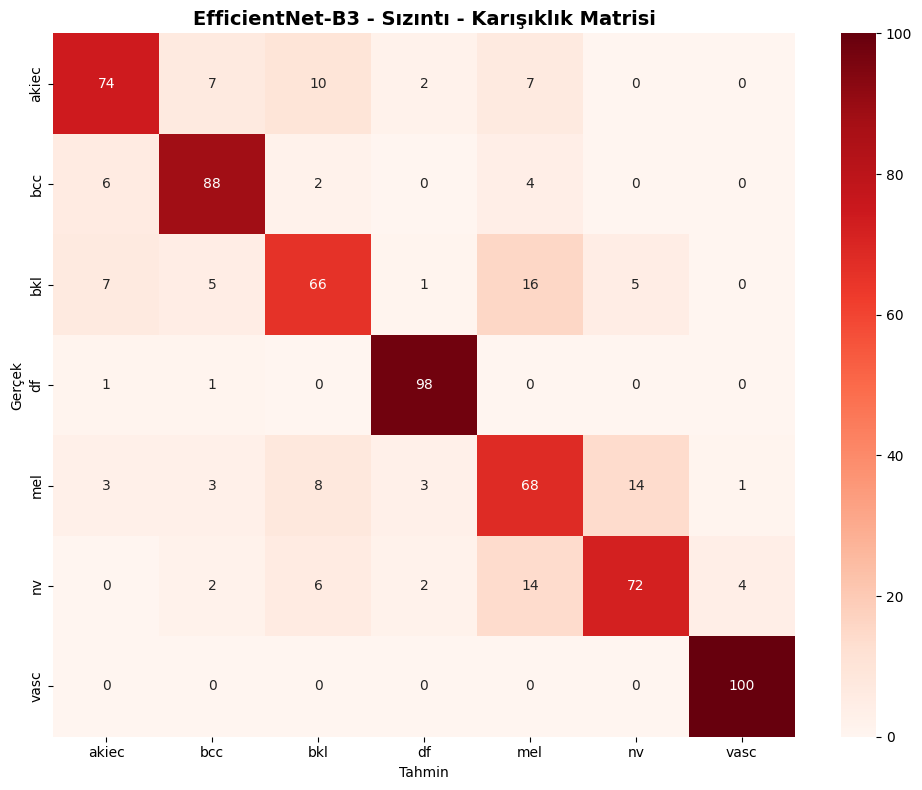

In [18]:
# ============ HÜCRE 18 — EfficientNet-B3 Değerlendirme (val) ============
checkpoint = torch.load(MODELS_LEAK_DIR / 'efficientnet_b3_WORST.pth', map_location=device, weights_only=False)
model = get_model('efficientnet_b3', num_classes=7, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader_worst:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc_b3_worst = accuracy_score(all_labels, all_preds)
macro_f1_b3_worst = f1_score(all_labels, all_preds, average='macro')
print(f"EfficientNet-B3 Sızıntı | Doğruluk %{acc_b3_worst*100:.2f} | Makro F1 %{macro_f1_b3_worst*100:.2f}")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('EfficientNet-B3 - Sızıntı - Karışıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout()
plt.savefig(FIG_DIR / 'efficientnet_b3_worst_leakage_cm.png', dpi=150)
plt.show()

# degerlendirme + test

Sızıntılı test seti: 700 resim


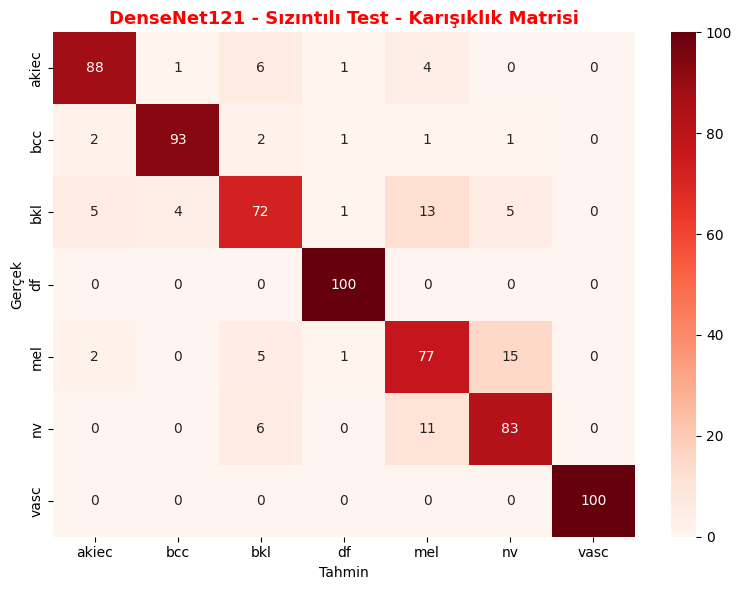

DenseNet121        Test Doğruluk %87.57


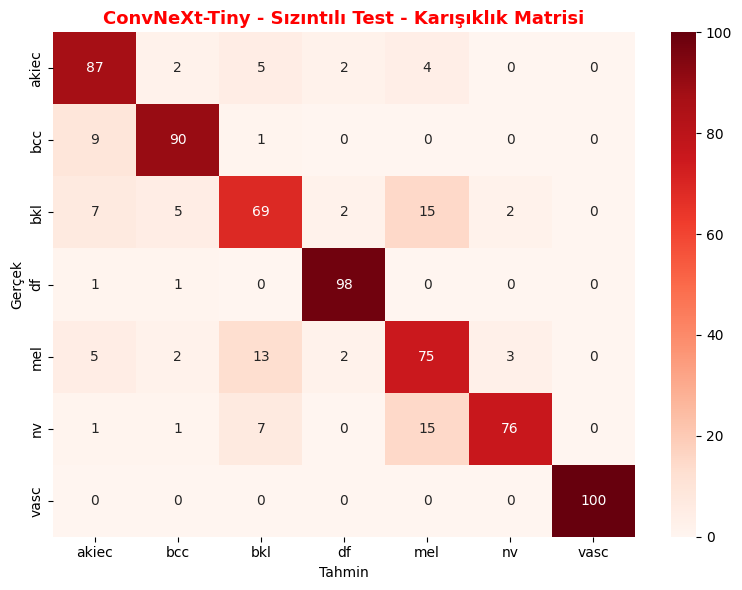

ConvNeXt-Tiny      Test Doğruluk %85.00


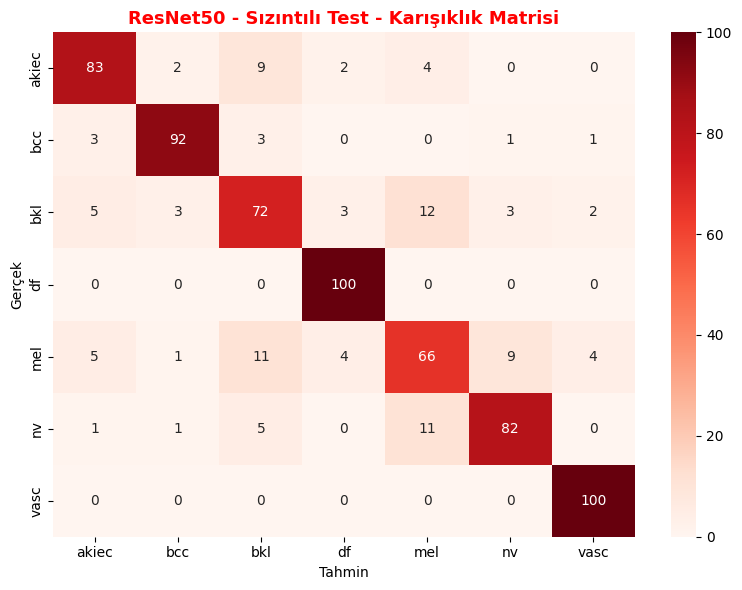

ResNet50           Test Doğruluk %85.00


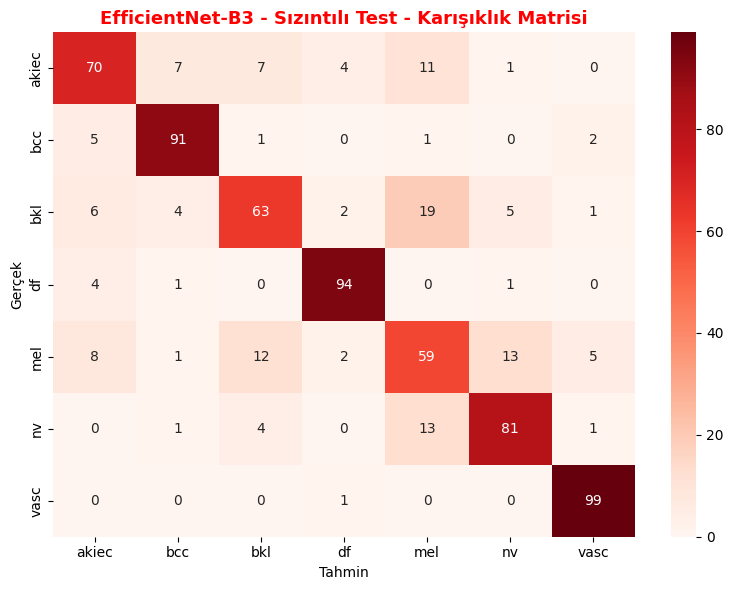

EfficientNet-B3    Test Doğruluk %79.57
Kaydedildi: F:\CancerDataClassification\results\leak_test_seed42.json


In [19]:
# ============ HÜCRE 19 — Test Seti Değerlendirme (4 model) + JSON KAYDET ============
test_dataset_worst = HAMDataset(
    csv_path=str(DATA / 'worst_test.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='test'))
test_loader_worst = DataLoader(test_dataset_worst, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=True)
print(f"Sızıntılı test seti: {len(test_dataset_worst)} resim")

test_models_worst = {
    'DenseNet121':     ('densenet121',     str(MODELS_LEAK_DIR / 'densenet121_WORST.pth')),
    'ConvNeXt-Tiny':   ('convnext_tiny',   str(MODELS_LEAK_DIR / 'convnext_tiny_WORST.pth')),
    'ResNet50':        ('resnet50',        str(MODELS_LEAK_DIR / 'resnet50_WORST.pth')),
    'EfficientNet-B3': ('efficientnet_b3', str(MODELS_LEAK_DIR / 'efficientnet_b3_WORST.pth')),
}

test_results_worst = {}
for model_name, (arch, ckpt_path) in test_models_worst.items():
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = get_model(arch, num_classes=7, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device).eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader_worst:
            outputs = model(imgs.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} - Sızıntılı Test - Karışıklık Matrisi', fontsize=13, fontweight='bold', color='red')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'test_worst_{arch}_cm.png', dpi=150)
    plt.show()

    test_results_worst[model_name] = {
        'acc': accuracy_score(all_labels, all_preds) * 100,
        'macro_f1': f1_score(all_labels, all_preds, average='macro') * 100,
        'weighted_f1': f1_score(all_labels, all_preds, average='weighted') * 100,
    }
    print(f"{model_name:<18} Test Doğruluk %{test_results_worst[model_name]['acc']:.2f}")

import json
out = BASE / f'results/leak_test_seed{SEED}.json'
out.parent.mkdir(parents=True, exist_ok=True)
with open(out, 'w') as f:
    json.dump(test_results_worst, f, indent=2)
print(f"Kaydedildi: {out}")

In [20]:
# ============ HÜCRE 20 — TÜM TOHUMLARI TOPLA (3 tohum bitince BİR KEZ çalıştır) ============
import json, numpy as np

seeds = [13, 21, 42]
models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
data = {m: [] for m in models}
for s in seeds:
    r = json.load(open(BASE / f'results/leak_test_seed{s}.json'))
    for m in models:
        data[m].append(r[m]['acc'])

print(f"{'Model':<18}{'Sizintili Test Dogruluk (ort ± std)':<36}")
print("-"*54)
for m in models:
    a = np.array(data[m])
    print(f"{m:<18}{a.mean():.2f} ± {a.std(ddof=1):.2f}")

Model             Sizintili Test Dogruluk (ort ± std) 
------------------------------------------------------
DenseNet121       86.95 ± 0.64
ConvNeXt-Tiny     84.48 ± 1.16
ResNet50          84.00 ± 1.00
EfficientNet-B3   79.38 ± 0.59


In [21]:
# ============ EK HÜCRE — Sızıntılı Test Detaylı Rapor (seed 13) ============
# NOT: SEED=13 iken çalıştır (o tohumun modelleri diskte olmalı)
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader

test_dataset_worst = HAMDataset(csv_path=str(DATA / 'worst_test.csv'), task='multiclass',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='test'))
test_loader_worst = DataLoader(test_dataset_worst, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

report_models = {
    'DenseNet121':     ('densenet121',     str(MODELS_LEAK_DIR / 'densenet121_WORST.pth')),
    'ConvNeXt-Tiny':   ('convnext_tiny',   str(MODELS_LEAK_DIR / 'convnext_tiny_WORST.pth')),
    'ResNet50':        ('resnet50',        str(MODELS_LEAK_DIR / 'resnet50_WORST.pth')),
    'EfficientNet-B3': ('efficientnet_b3', str(MODELS_LEAK_DIR / 'efficientnet_b3_WORST.pth')),
}
for model_name, (arch, ckpt) in report_models.items():
    checkpoint = torch.load(ckpt, map_location=device, weights_only=False)
    model = get_model(arch, num_classes=7, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict']); model = model.to(device).eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader_worst:
            all_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
    print("="*70); print(f"SIZINTILI TEST: {model_name}"); print("="*70)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

SIZINTILI TEST: DenseNet121
              precision    recall  f1-score   support

       akiec      0.907     0.880     0.893       100
         bcc      0.949     0.930     0.939       100
         bkl      0.791     0.720     0.754       100
          df      0.962     1.000     0.980       100
         mel      0.726     0.770     0.748       100
          nv      0.798     0.830     0.814       100
        vasc      1.000     1.000     1.000       100

    accuracy                          0.876       700
   macro avg      0.876     0.876     0.875       700
weighted avg      0.876     0.876     0.875       700

SIZINTILI TEST: ConvNeXt-Tiny
              precision    recall  f1-score   support

       akiec      0.791     0.870     0.829       100
         bcc      0.891     0.900     0.896       100
         bkl      0.726     0.690     0.708       100
          df      0.942     0.980     0.961       100
         mel      0.688     0.750     0.718       100
          nv      0.

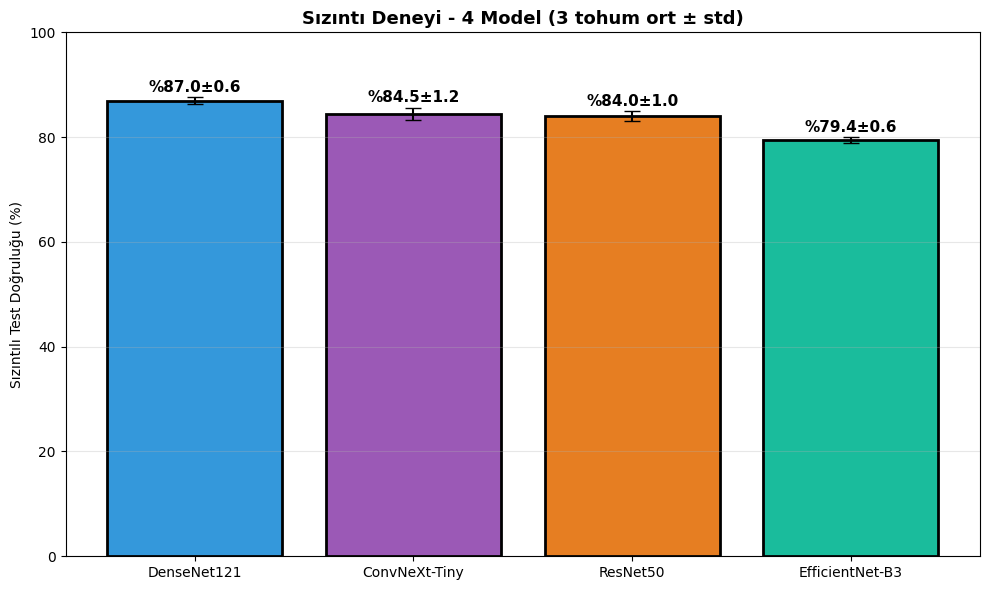

In [22]:
# ============ EK HÜCRE — Sızıntılı 4 Model Özet Grafik (3 tohum) ============
# NOT: 3 tohum bittikten sonra bir kez çalıştır (HÜCRE 20 gibi)
import json, numpy as np, matplotlib.pyplot as plt
seeds = [13, 21, 42]
models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
data = {m: [] for m in models}
for s in seeds:
    r = json.load(open(BASE / f'results/leak_test_seed{s}.json'))
    for m in models: data[m].append(r[m]['acc'])

means = [np.mean(data[m]) for m in models]; stds = [np.std(data[m], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, means, yerr=stds, capsize=6,
              color=['#3498db','#9b59b6','#e67e22','#1abc9c'], edgecolor='black', linewidth=2)
for b, mn, sd in zip(bars, means, stds):
    ax.text(b.get_x()+b.get_width()/2, mn+sd+0.4, f'%{mn:.1f}±{sd:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Sızıntılı Test Doğruluğu (%)'); ax.set_ylim(0, 100)
ax.set_title('Sızıntı Deneyi - 4 Model (3 tohum ort ± std)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(BASE / 'results/figures/leak_4model_errorbar.png', dpi=150); plt.show()